,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Shape: (918, 12)
Decision Tree Accuracy: 0.8369565217391305


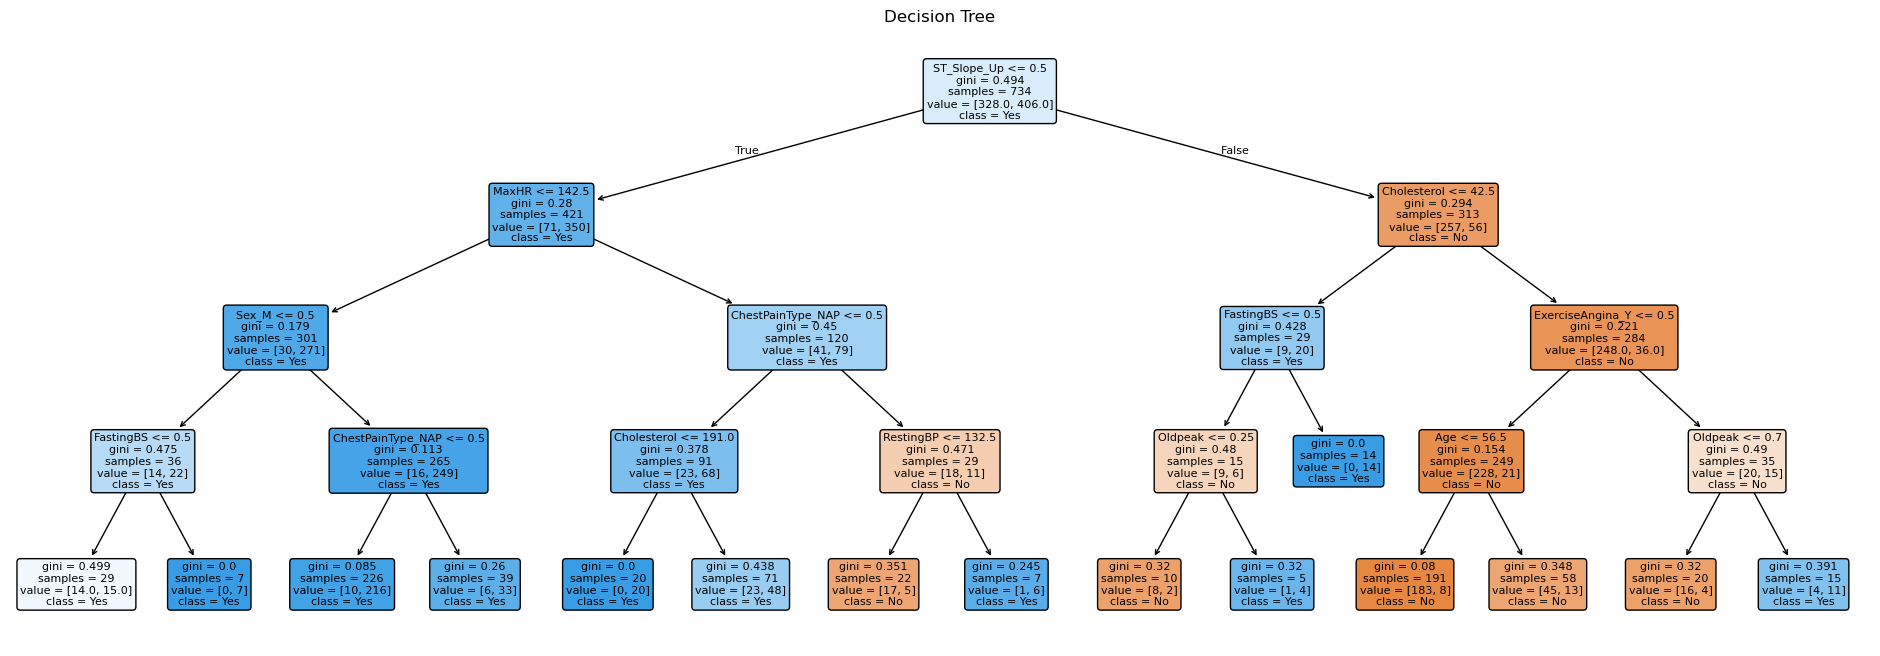

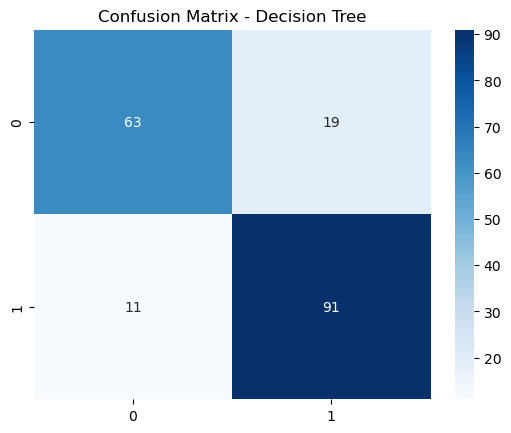

Linear Regression Accuracy: 0.8913043478260869


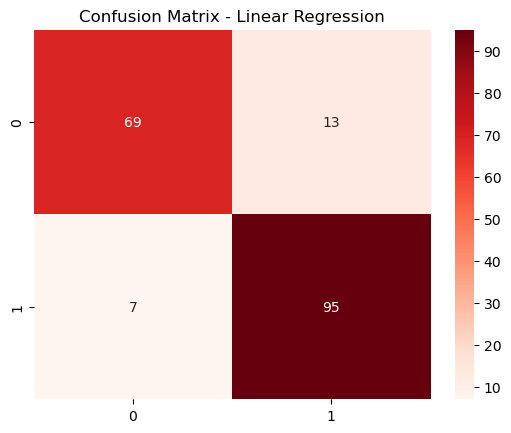

Logistic Regression Accuracy: 0.8858695652173914


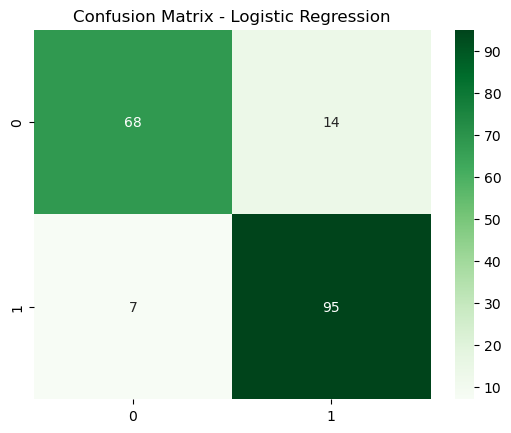

Naive Bayes Accuracy: 0.9130434782608695


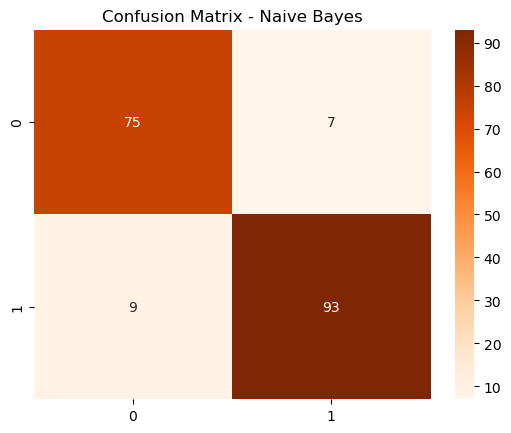

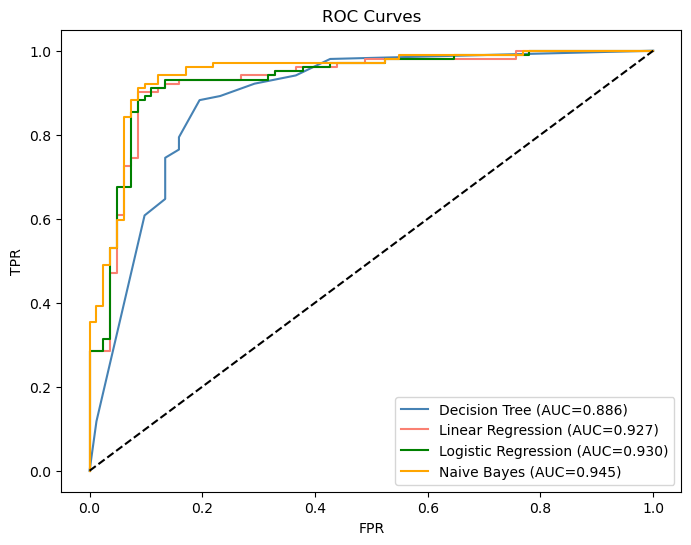

,Accuracy,Precision,Recall,F1
Model,,,,
Decision Tree,0.8370,0.8273,0.8922,0.8585
Linear Regression,0.8913,0.8796,0.9314,0.9048
Logistic Regression,0.8859,0.8716,0.9314,0.9005
Naive Bayes,0.9130,0.9300,0.9118,0.9208


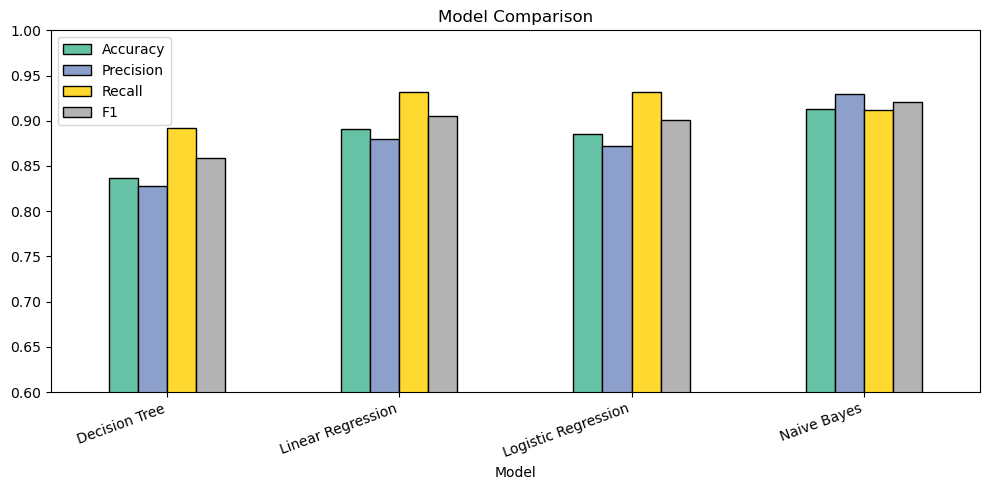

In [1]:
import micropip
await micropip.install(['seaborn', 'scikit-learn'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_curve,
                              roc_auc_score, f1_score, precision_score, recall_score)

# ── 2. LOAD (Pyodide-safe way) ────────────────────────────────────────────────
from pyodide.http import pyfetch
response = await pyfetch("https://raw.githubusercontent.com/violamakishtii/Heart-Labwork/main/heart.csv")
with open("heart.csv", "wb") as f:
    f.write(await response.bytes())

df = pd.read_csv('heart.csv')
display(df.head())
print('Shape:', df.shape)

df_encoded = pd.get_dummies(df, columns=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope'], drop_first=True)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── 3. DECISION TREE ──────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

plt.figure(figsize=(24,8))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['No','Yes'], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree'); plt.show()

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree'); plt.show()

# ── 4. LINEAR REGRESSION ──────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr_raw = lr.predict(X_test_s)
y_pred_lr = (y_pred_lr_raw >= 0.5).astype(int)
print("Linear Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Linear Regression'); plt.show()

# ── 5. LOGISTIC REGRESSION ────────────────────────────────────────────────────
log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_train_s, y_train)
y_pred_log = log.predict(X_test_s)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression'); plt.show()

# ── 6. NAIVE BAYES ────────────────────────────────────────────────────────────
nb = GaussianNB()
nb.fit(X_train_s, y_train)
y_pred_nb = nb.predict(X_test_s)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Naive Bayes'); plt.show()

# ── 7. ROC CURVES ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8,6))
for name, proba, color in [
    ('Decision Tree',       dt.predict_proba(X_test)[:,1],    'steelblue'),
    ('Linear Regression',   y_pred_lr_raw,                    'salmon'),
    ('Logistic Regression', log.predict_proba(X_test_s)[:,1], 'green'),
    ('Naive Bayes',         nb.predict_proba(X_test_s)[:,1],  'orange'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', color=color)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves'); plt.legend(); plt.show()

# ── 8. SUMMARY ────────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':     ['Decision Tree', 'Linear Regression', 'Logistic Regression', 'Naive Bayes'],
    'Accuracy':  [accuracy_score(y_test, p)  for p in [y_pred_dt, y_pred_lr, y_pred_log, y_pred_nb]],
    'Precision': [precision_score(y_test, p) for p in [y_pred_dt, y_pred_lr, y_pred_log, y_pred_nb]],
    'Recall':    [recall_score(y_test, p)    for p in [y_pred_dt, y_pred_lr, y_pred_log, y_pred_nb]],
    'F1':        [f1_score(y_test, p)        for p in [y_pred_dt, y_pred_lr, y_pred_log, y_pred_nb]],
}).set_index('Model').round(4)

display(results)
results.plot(kind='bar', figsize=(10,5), colormap='Set2', edgecolor='black', ylim=(0.6,1.0))
plt.title('Model Comparison'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()